# 📌 Tugas 7 - Exploratory Data Analysis

> Copy template ini lalu kerjakan menggunakan template ini.

> Referensi untuk mengerjakan tugas :
> - https://colab.research.google.com/drive/1cCozod_L1um-5E4YDhD2RLoNXRNoylq9?usp=sharing
> - https://colab.research.google.com/drive/1_5ehUVxBed28qwAPLcR0C9aaYoaPiNZ3?usp=sharing
> - https://colab.research.google.com/drive/15KuXtQRyhSbMoimVmi0zjE06e9EwKT6s?usp=sharing
> - https://colab.research.google.com/drive/10BuLMoi9megpSFmn9AcYSXt8z6xCo3hT?usp=sharing

---

Tugas ini bertujuan untuk membantu kalian memahami Exploratory Data Analysis
Silakan download dataset di : https://www.kaggle.com/datasets/imdevskp/corona-virus-report lalu **pilih yang Worldometer.**

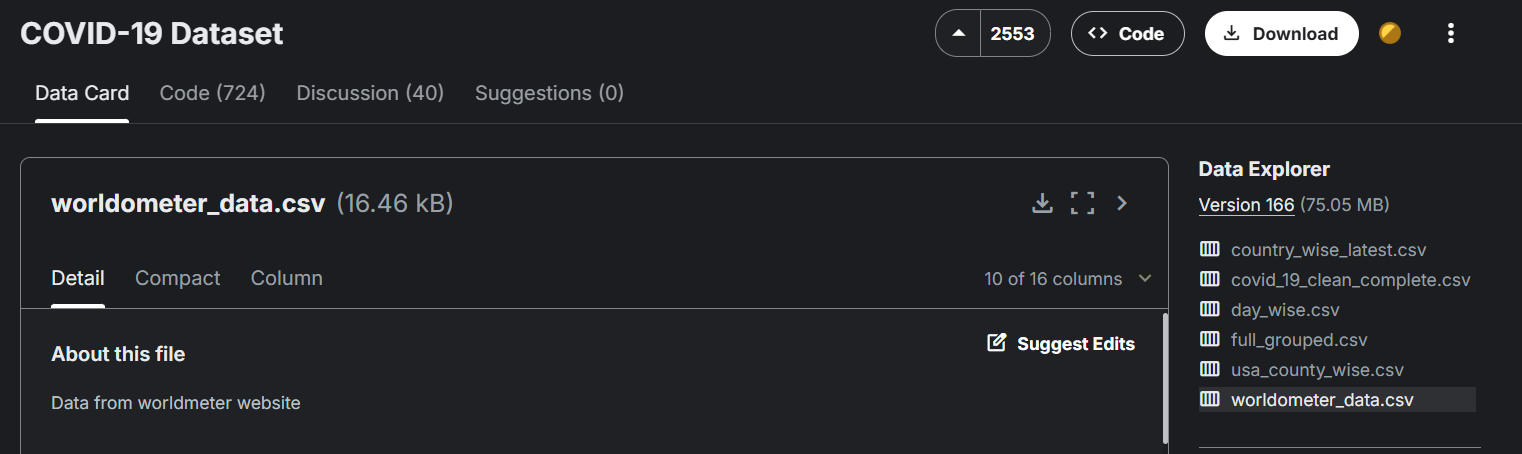

- Nama lengkap : Muhammad Sirojul Fuad
- Program : AI Development

Setiap langkah, setiap cell terdapat 'insight' hasil analisis dari kode yang dijalankan. Berikan insight sesuai dengan cell yang dijalankan.

**0. Import module yang diperlukan**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas

> Cek tipe data dan missing value

> Tampilkan statistik deskriptif

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df = pd.read_csv('/content/drive/MyDrive/IL/7/worldometer_data.csv')

print("5 Data Teratas")
display(df.head())

5 Data Teratas


,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [7]:
print("5 Data Terbawah")
display(df.tail())

5 Data Terbawah


,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
204,Montserrat,North America,4992.0,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,26247.0,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3489.0,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,801.0,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe
208,Western Sahara,Africa,598682.0,10,NaN,1.0,NaN,8.0,NaN,1.0,NaN,17.0,2.0,NaN,NaN,Africa


In [12]:
df.info()

print("\n Jumlah Missing Value per Kolom")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   NewCases          4 non-null      float64
 5   TotalDeaths       188 non-null    float64
 6   NewDeaths         3 non-null      float64
 7   TotalRecovered    205 non-null    float64
 8   NewRecovered      3 non-null      float64
 9   ActiveCases       205 non-null    float64
 10  Serious,Critical  122 non-null    float64
 11  Tot Cases/1M pop  208 non-null    float64
 12  Deaths/1M pop     187 non-null    float64
 13  TotalTests        191 non-null    float64
 14  Tests/1M pop      191 non-null    float64
 15  WHO Region        184 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory u

,Missing Count,Missing (%)
NewDeaths,206,98.56
NewRecovered,206,98.56
NewCases,205,98.09
"Serious,Critical",87,41.63
WHO Region,25,11.96
Deaths/1M pop,22,10.53
TotalDeaths,21,10.05
TotalTests,18,8.61
Tests/1M pop,18,8.61
TotalRecovered,4,1.91


In [15]:
# Statistik deskriptif
display(df.describe().T.round(2))

print(f"\nJumlah Negara/Wilayah : {df['Country/Region'].nunique()}")
print(f"Jumlah Benua         : {df['Continent'].nunique()}")
print(f"Daftar Benua         : {sorted(df['Continent'].dropna().unique().tolist())}")

,count,mean,std,min,25%,50%,75%,max
Population,208.0,30415486.97,1.047661e+08,801.00,966314.00,7041972.5,25756135.50,1.381345e+09
TotalCases,209.0,91718.50,4.325867e+05,10.00,712.00,4491.0,36896.00,5.032179e+06
NewCases,4.0,1980.50,3.129610e+03,20.00,27.50,656.0,2609.00,6.590000e+03
TotalDeaths,188.0,3792.59,1.548718e+04,1.00,22.00,113.0,786.00,1.628040e+05
NewDeaths,3.0,300.00,4.512000e+02,1.00,40.50,80.0,449.50,8.190000e+02
TotalRecovered,205.0,58878.98,2.566984e+05,7.00,334.00,2178.0,20553.00,2.576668e+06
NewRecovered,3.0,1706.00,2.154780e+03,42.00,489.00,936.0,2538.00,4.140000e+03
ActiveCases,205.0,27664.33,1.746327e+05,0.00,86.00,899.0,7124.00,2.292707e+06
"Serious,Critical",122.0,534.39,2.047520e+03,1.00,3.25,27.5,160.25,1.829600e+04
Tot Cases/1M pop,208.0,3196.02,5.191990e+03,3.00,282.00,1015.0,3841.75,3.992200e+04



Jumlah Negara/Wilayah : 209
Jumlah Benua         : 6
Daftar Benua         : ['Africa', 'Asia', 'Australia/Oceania', 'Europe', 'North America', 'South America']


Insight :

> Dataset berisi 209 negara/wilayah yang terbagi 6 benua. Total terdapat 14 kolom yang memiliki missing value. Kolom dengan missing value terbanyak adalah `NewCases`, `NewDeaths`,  `NewRecovered` >98% karena kolom ini hanya berisi data harian dan tidak selalu tersedia.
 Kolom `TotalTests` dan `Tests/1M pop` masing-masing memiliki 8.61% missing value, menunjukkan tidak semua negara melaporkan data pengujian. Dari statistik deskriptif, nilai rata-rata TotalCases
 (91.718) jauh lebih besar dari median (4.491), mengkonfirmasi distribusi yang sangat skewed ke kanan  sebagian kecil negara mendominasi jumlah kasus global.

**2. Analisis Distribusi**

> Plot distribusi TotalCases, TotalDeaths, dan TotalRecovered

> Buat histogram log-skala untuk kolom TotalCases

> Bandingkan populasi terhadap jumlah kasus (scatter plot)

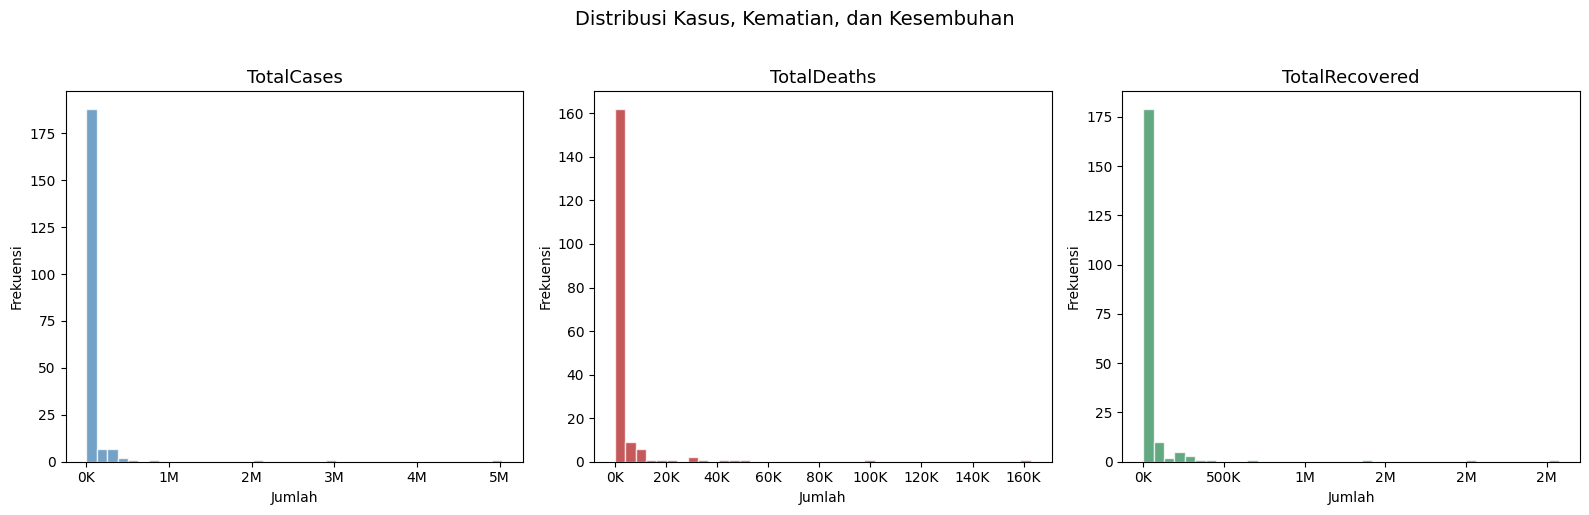

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols = ['TotalCases', 'TotalDeaths', 'TotalRecovered']
colors = ['steelblue', 'firebrick', 'seagreen']

for ax, col, color in zip(axes, cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Jumlah')
    ax.set_ylabel('Frekuensi')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.suptitle('Distribusi Kasus, Kematian, dan Kesembuhan', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

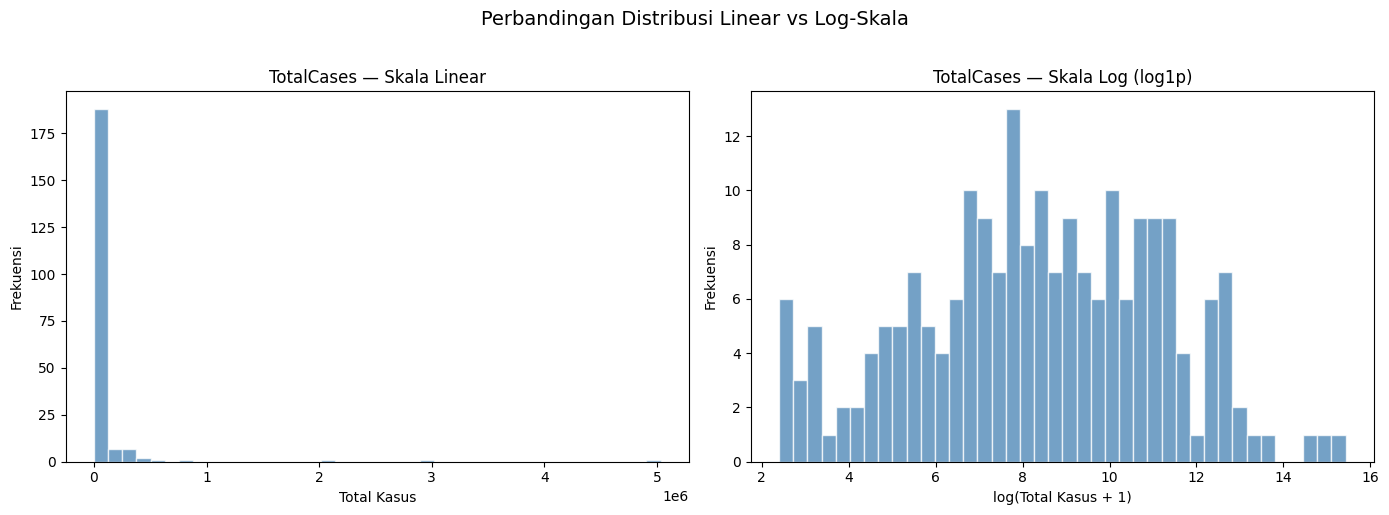

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['TotalCases'].dropna(), bins=40, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_title('TotalCases — Skala Linear')
axes[0].set_xlabel('Total Kasus')

axes[1].hist(np.log1p(df['TotalCases'].dropna()), bins=40, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].set_title('TotalCases — Skala Log (log1p)')
axes[1].set_xlabel('log(Total Kasus + 1)')

for ax in axes:
    ax.set_ylabel('Frekuensi')

plt.suptitle('Perbandingan Distribusi Linear vs Log-Skala', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

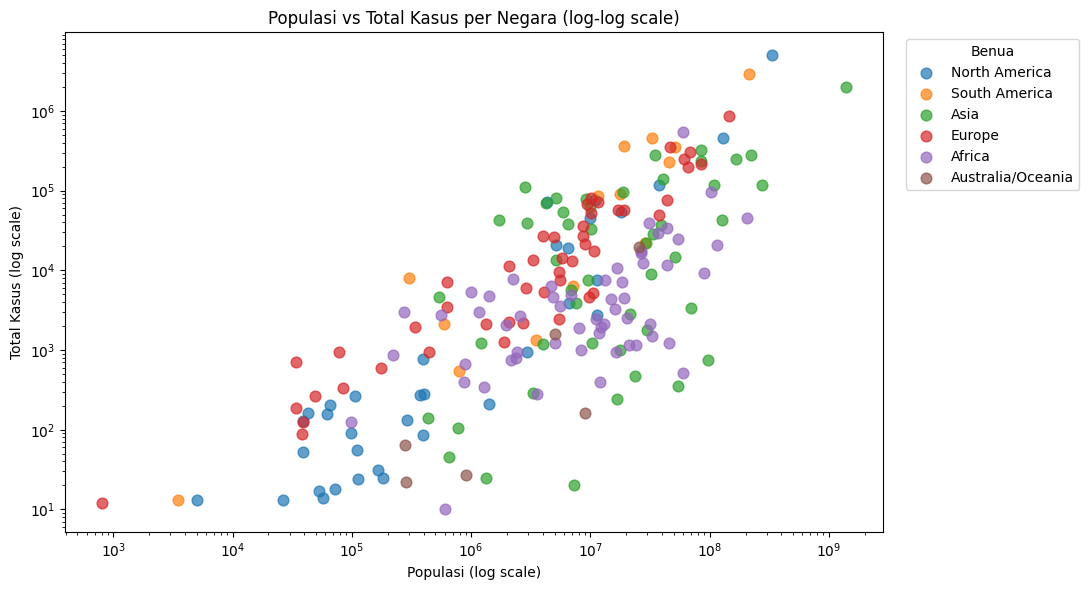

In [18]:
df_plot = df.dropna(subset=['Population', 'TotalCases', 'Continent'])

plt.figure(figsize=(11, 6))
continents = df_plot['Continent'].unique()
palette = sns.color_palette('tab10', len(continents))

for continent, color in zip(continents, palette):
    subset = df_plot[df_plot['Continent'] == continent]
    plt.scatter(subset['Population'], subset['TotalCases'],
                label=continent, alpha=0.7, s=60, color=color)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Populasi (log scale)')
plt.ylabel('Total Kasus (log scale)')
plt.title('Populasi vs Total Kasus per Negara (log-log scale)')
plt.legend(title='Benua', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight :

> Distribusi TotalCases, TotalDeaths, dan TotalRecovered semuanya sangat right-skewed yang mana mayoritas negara memiliki angka rendah, sementara negara seperti USA  menjadi outlier ekstrem.  Pada histogram log-skala, distribusi TotalCases mendekati normal (bell curve), menandakan pola  pertumbuhan kasus tidak linear. Scatter plot populasi vs total kasus menunjukkan korelasi positif moderat dimana  negara berpopulasi besar cenderung memiliki lebih banyak kasus,namun tidak bersifat deterministik karena faktor kebijakan penanganan turut menentukan.

**3. Analisis Per Benua (Continent)**

> Hitung total kasus, kematian, dan kesembuhan per benua

> Visualisasikan perbandingan kasus dan kematian antar benua

In [20]:
continent_df = df.groupby('Continent', dropna=True).agg(
    TotalCases=('TotalCases', 'sum'),
    TotalDeaths=('TotalDeaths', 'sum'),
    TotalRecovered=('TotalRecovered', 'sum'),
    TotalTests=('TotalTests', 'sum'),
    Negara=('Country/Region', 'count')
).reset_index().sort_values('TotalCases', ascending=False)

print("Total per Benua")
display(continent_df)

Total per Benua


,Continent,TotalCases,TotalDeaths,TotalRecovered,TotalTests,Negara
4,North America,5919209,229855.0,3151678.0,70173584.0,35
1,Asia,4689794,100627.0,3508170.0,65353821.0,48
5,South America,4543273,154885.0,3116150.0,22379618.0,14
3,Europe,2982576,205232.0,1587302.0,96125611.0,48
0,Africa,1011867,22114.0,693620.0,8673853.0,57
2,Australia/Oceania,21735,281.0,12620.0,5152811.0,6


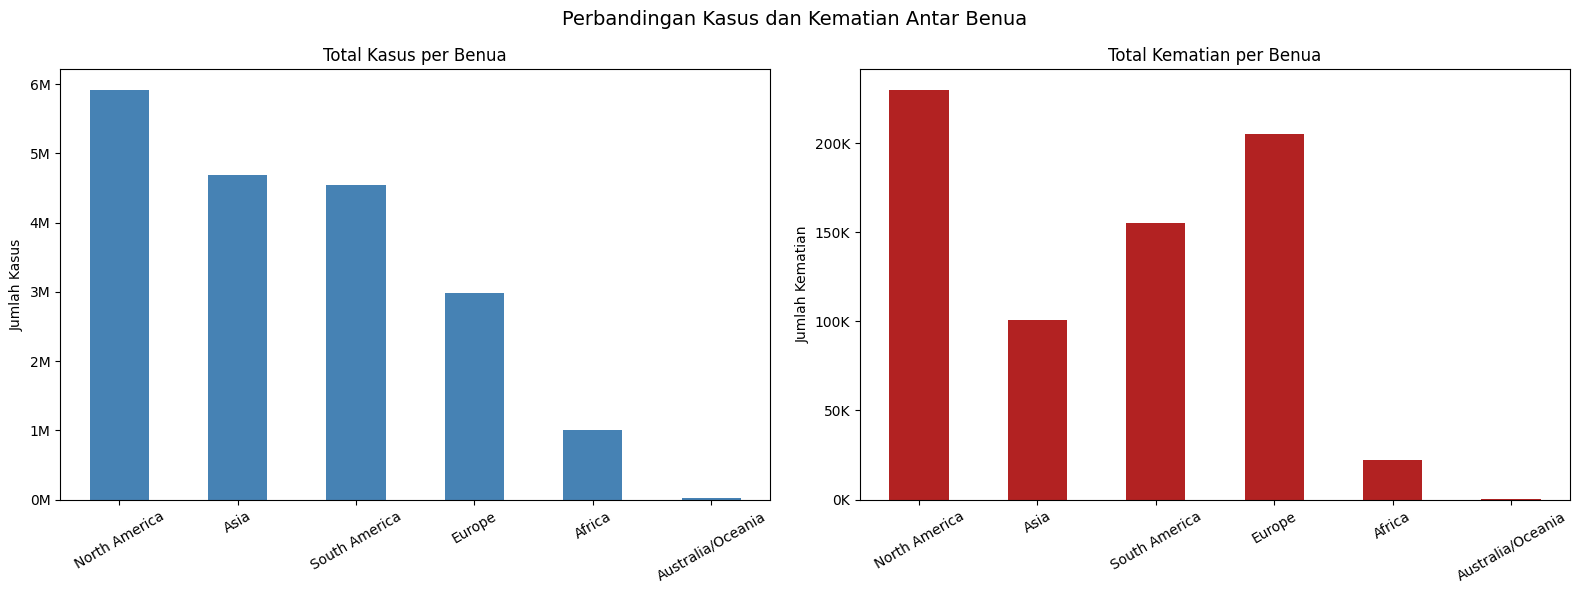

In [22]:
# Visualisasi Bar chart kasus & kematian per benua
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

continent_df.plot(kind='bar', x='Continent', y='TotalCases',
                  ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Total Kasus per Benua')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah Kasus')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M'))
axes[0].tick_params(axis='x', rotation=30)

continent_df.plot(kind='bar', x='Continent', y='TotalDeaths',
                  ax=axes[1], color='firebrick', legend=False)
axes[1].set_title('Total Kematian per Benua')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Kematian')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Perbandingan Kasus dan Kematian Antar Benua', fontsize=14)
plt.tight_layout()
plt.show()

Insight :

> North America memimpin total kasus (5.919.209), diikuti Asia (4.689.794) dan South America (4.543.273). Namun yang menarik, Europe hanya berada di urutan ke-4 dalam total kasus, tetapi  memiliki total kematian ke-2 tertinggi (205.232) hampir menyamai North America (229.855). Ini mengindikasikan death rate Europe relatif lebih tinggi dibanding Asia dan South America. Africa mencatat kasus terendah kedua (1.011.867) meski memiliki jumlah negara terbanyak (57 negara),
yang kemungkinan mencerminkan keterbatasan kapasitas pengujian, bukan kondisi pandemi yang lebih baik. Australia/Oceania memiliki kasus dan kematian terendah berkat keunggulan geografis berupa isolasi alami.

**4. Analisis Tes dan Positivity Rate**
> Buat kolom baru "Positivity Rate" = TotalCases / TotalTests

> Analisis negara-negara dengan positivity rate tertinggi

In [24]:
# Buat kolom Positivity Rate
df['Positivity_Rate'] = (df['TotalCases'] / df['TotalTests']) * 100

print("Statistik Positivity Rate")
print(df['Positivity_Rate'].describe().round(2))

df_pos = df.dropna(subset=['Positivity_Rate']).copy()
print(f"\nNegara dengan data Positivity Rate: {len(df_pos)}")

Statistik Positivity Rate
count     191.00
mean       32.58
std       236.85
min         0.07
25%         1.36
50%         4.34
75%        12.49
max      2937.66
Name: Positivity_Rate, dtype: float64

Negara dengan data Positivity Rate: 191


,Country/Region,TotalCases,TotalTests,Positivity_Rate
0,Sudan,11780,401.0,2937.66
1,Yemen,1768,120.0,1473.33
2,Guinea-Bissau,2032,1500.0,135.47
3,Suriname,2096,2785.0,75.26
4,Egypt,95006,135000.0,70.37
5,Guinea,7664,14407.0,53.20
6,Bolivia,86423,183583.0,47.08
7,Mexico,462690,1056915.0,43.78
8,Honduras,45098,109292.0,41.26
9,Haiti,7544,18443.0,40.90


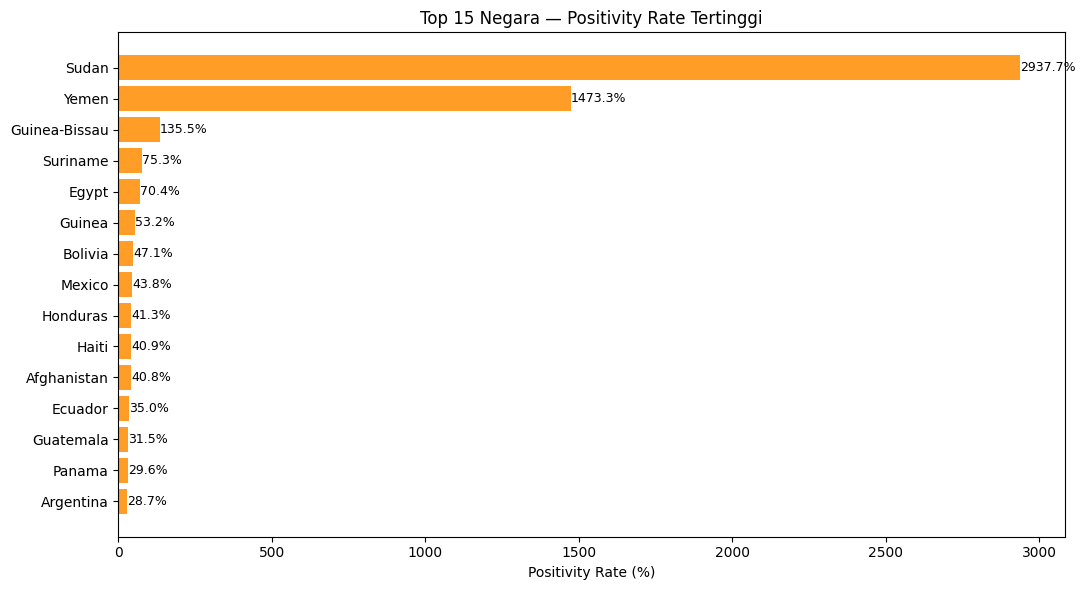

In [26]:
top_pos = df_pos.nlargest(15, 'Positivity_Rate')[
    ['Country/Region', 'TotalCases', 'TotalTests', 'Positivity_Rate']
].reset_index(drop=True)

display(top_pos.round(2))

plt.figure(figsize=(11, 6))
plt.barh(top_pos['Country/Region'][::-1],
         top_pos['Positivity_Rate'][::-1], color='darkorange', alpha=0.85)
plt.xlabel('Positivity Rate (%)')
plt.title('Top 15 Negara — Positivity Rate Tertinggi')
for i, v in enumerate(top_pos['Positivity_Rate'][::-1]):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Insight :

> Sudan memiliki positivity rate tertinggi yang ekstrem yaitu 2937.66% artinya jumlah kasus yang dilaporkan (11.780) jauh melebihi jumlah tes yang dilakukan (hanya 401 tes). Ini adalah indikasi kuat bahwa Sudan sangat kekurangan kapasitas pengujian dan kasusnya hampir pasti  jauh lebih banyak dari yang tercatat. Yemen juga mengalami situasi serupa (1473.33%). Dari 191 negara yang memiliki data, median positivity rate adalah 4.34% (mendekati standar WHO sebesar < 5%), namun rata-rata yang sangat tinggi (32.58%) menunjukkan adanya outlier ekstrem. Sebagian besar negara dengan positivity rate tinggi berasal dari Afrika dan Amerika Latin yang merupakan kawasan dengan akses pengujian terbatas.

**5. Death Rate & Recovery Rate**
> Buat kolom baru "Death Rate" = TotalDeaths / TotalCases

> Buat kolom "Recovery Rate" = TotalRecovered / TotalCases

> Bandingkan death rate dan recovery rate secara global

In [28]:
df['Death_Rate']    = (df['TotalDeaths']    / df['TotalCases']) * 100
df['Recovery_Rate'] = (df['TotalRecovered'] / df['TotalCases']) * 100

print("Death Rate (%)")
print(df['Death_Rate'].describe().round(4))
print("\n Recovery Rate (%)")
print(df['Recovery_Rate'].describe().round(4))

Death Rate (%)
count    188.0000
mean       3.2655
std        3.3918
min        0.0495
25%        1.3137
50%        2.2367
75%        4.0293
max       28.7330
Name: Death_Rate, dtype: float64

 Recovery Rate (%)
count    205.0000
mean      71.2476
std       22.0459
min        7.8358
25%       55.0075
50%       76.2782
75%       89.0858
max      100.0000
Name: Recovery_Rate, dtype: float64


In [29]:
global_total_cases     = df['TotalCases'].sum()
global_total_deaths    = df['TotalDeaths'].sum()
global_total_recovered = df['TotalRecovered'].sum()

global_dr = global_total_deaths    / global_total_cases * 100
global_rr = global_total_recovered / global_total_cases * 100

print(f"Global Death Rate    : {global_dr:.2f}%")
print(f"Global Recovery Rate : {global_rr:.2f}%")

Global Death Rate    : 3.72%
Global Recovery Rate : 62.97%


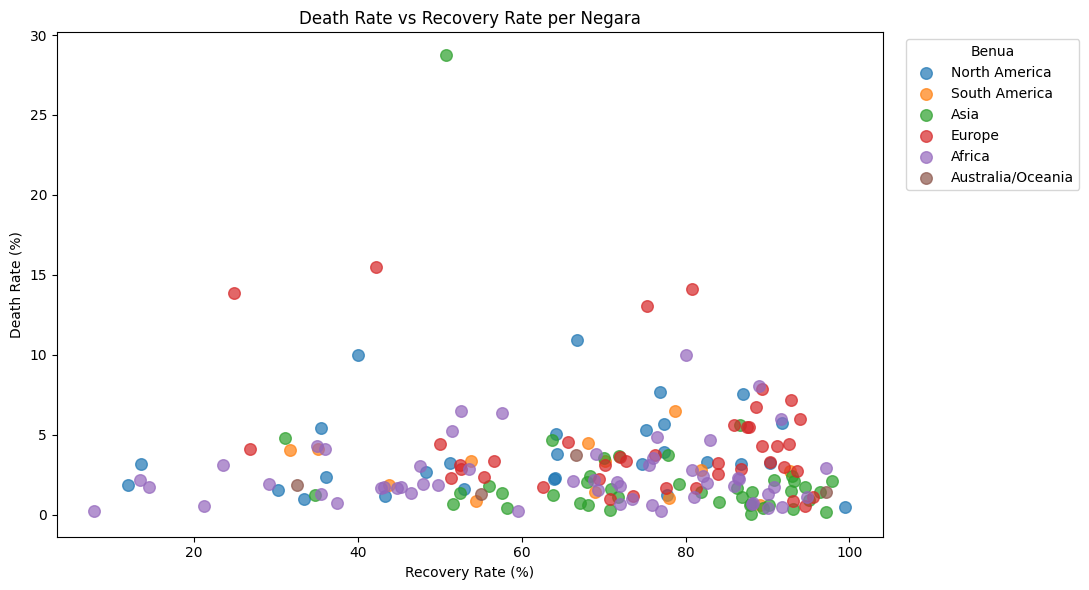

In [31]:
df_rate = df.dropna(subset=['Death_Rate', 'Recovery_Rate', 'Continent']).copy()
df_rate = df_rate[(df_rate['Death_Rate'] <= 100) & (df_rate['Recovery_Rate'] <= 100)]

plt.figure(figsize=(11, 6))
continents = df_rate['Continent'].unique()
palette = sns.color_palette('tab10', len(continents))

for continent, color in zip(continents, palette):
    sub = df_rate[df_rate['Continent'] == continent]
    plt.scatter(sub['Recovery_Rate'], sub['Death_Rate'],
                label=continent, alpha=0.7, s=70, color=color)

plt.xlabel('Recovery Rate (%)')
plt.ylabel('Death Rate (%)')
plt.title('Death Rate vs Recovery Rate per Negara')
plt.legend(title='Benua', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight :

> Sebagian besar negara berkumpul di area kanan bawah (recovery rate 70–100%, death rate 0–7%), artinya mayoritas negara sudah mencapai kesembuhan tinggi dengan kematian rendah. Terdapat outlier mencolok: satu negara Asia dengan death rate ~28.8% (kemungkinan Yemen)
dan beberapa negara Eropa dengan death rate 13–15% meski recovery rate-nya masih rendah  mencerminkan gelombang awal yang sangat mematikan di kawasan tersebut. Afrika banyak berada di sisi kiri (recovery rate rendah), bukan karena kematian tinggi, melainkan karena banyak kasus aktif yang belum terselesaikan saat data diambil.

**6. Serious/Critical Case Analysis**

> Visualisasi negara dengan jumlah kasus kritis tertinggi

> Bandingkan dengan jumlah kasus aktif

,Country/Region,TotalCases,ActiveCases,Critical
0,USA,5032179,2292707.0,18296.0
1,India,2025409,606387.0,8944.0
2,Brazil,2917562,771258.0,8318.0
3,Iran,320117,24678.0,4156.0
4,Mexico,462690,103325.0,3987.0
5,Russia,871894,180931.0,2300.0
6,Canada,118561,6489.0,2263.0
7,Saudi Arabia,284226,34082.0,1915.0
8,Colombia,357710,153416.0,1493.0
9,Peru,455409,124648.0,1426.0


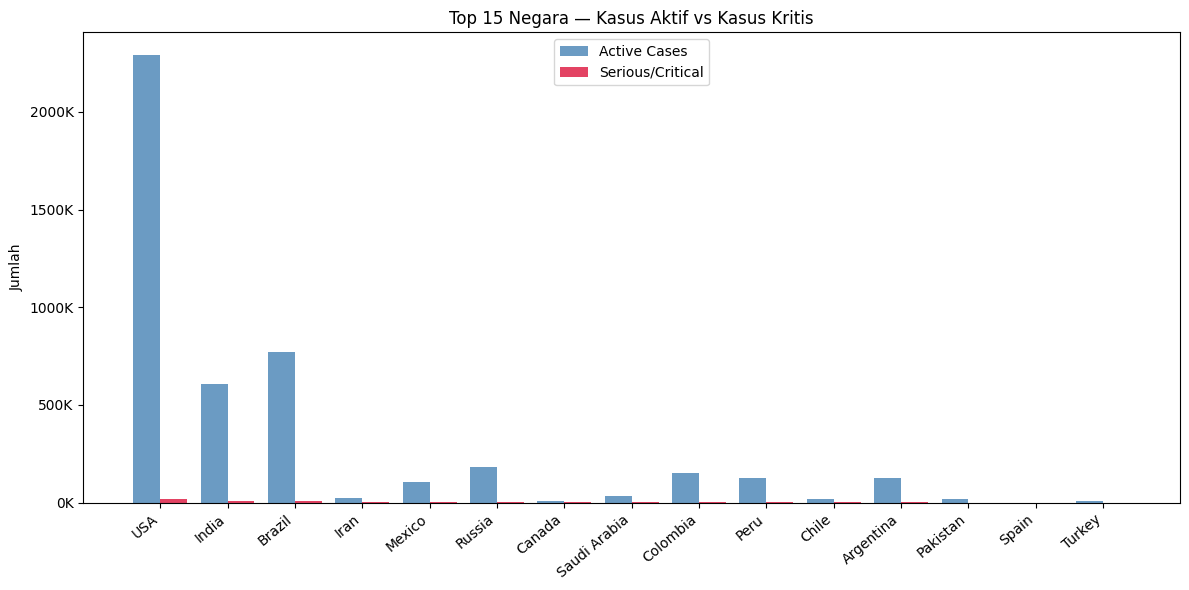

In [32]:
df_serious = df.dropna(subset=['Serious,Critical']).copy()
df_serious = df_serious.rename(columns={'Serious,Critical': 'Critical'})
top_critical = df_serious.nlargest(15, 'Critical')[
    ['Country/Region', 'TotalCases', 'ActiveCases', 'Critical']
].reset_index(drop=True)

display(top_critical)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top_critical))
width = 0.4
ax.bar([i - width/2 for i in x], top_critical['ActiveCases'], width,
       label='Active Cases', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], top_critical['Critical'], width,
       label='Serious/Critical', color='crimson', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(top_critical['Country/Region'], rotation=40, ha='right')
ax.set_ylabel('Jumlah')
ax.set_title('Top 15 Negara — Kasus Aktif vs Kasus Kritis')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

In [34]:
# Rasio kritis per aktif
df_serious['Critical_Ratio'] = (df_serious['Critical'] / df_serious['ActiveCases']) * 100
top_ratio = df_serious.dropna(subset=['Critical_Ratio']).nlargest(10, 'Critical_Ratio')[
    ['Country/Region', 'ActiveCases', 'Critical', 'Critical_Ratio']
]
display(top_ratio.round(2))

,Country/Region,ActiveCases,Critical,Critical_Ratio
23,Canada,6489.0,2263.0,34.87
10,Iran,24678.0,4156.0,16.84
185,Monaco,16.0,2.0,12.50
192,Saint Martin,9.0,1.0,11.11
156,Diamond Princess,48.0,4.0,8.33
7,Chile,16614.0,1358.0,8.17
187,Antigua and Barbuda,13.0,1.0,7.69
137,Jordan,50.0,3.0,6.00
12,Saudi Arabia,34082.0,1915.0,5.62
68,El Salvador,9377.0,509.0,5.43


Insight :

> USA mendominasi kasus kritis secara absolut dengan 18.296 kasus kritis dari 2.292.707 kasus aktif. India (8.944 kritis) dan Brazil (8.318 kritis) mengikuti di posisi ke-2 dan ke-3. Yang menarik adalah Iran yang memiliki kasus kritis tinggi (4.156) padahal total kasusnya (320.117) jauh lebih kecil dibanding USA, Brazil, atau India mengindikasikan tekanan ICU  yang sangat berat di Iran. Canada juga mencuri perhatian: dengan hanya 6.489 kasus aktif, namun 2.263 kasus kritis, rasio kritis/aktifnya sangat tinggi (~34.9%), mungkin mencerminkan pasien yang dirawat adalah kasus berat karena kasus ringan sudah sembuh lebih cepat.

**7. Negara dengan Performa Terbaik & Terburuk**

> Tampilkan top 10 negara dengan recovery rate tertinggi

> Tampilkan top 10 negara dengan death rate tertinggi

> Tampilkan top 10 negara dengan tests per 1M tertinggi

,Country/Region,TotalCases,TotalDeaths,TotalRecovered,Recovery_Rate
0,New Zealand,1569,22.0,1524.0,97.13
1,Qatar,112092,178.0,108831.0,97.09
2,Malaysia,9038,125.0,8713.0,96.40
3,Jordan,1232,11.0,1171.0,95.05
4,Djibouti,5330,59.0,5057.0,94.88
5,Iceland,1930,10.0,1825.0,94.56
6,Thailand,3330,58.0,3148.0,94.53
7,Norway,9468,256.0,8857.0,93.55
8,S. Korea,14519,303.0,13543.0,93.28
9,Bahrain,42889,156.0,39945.0,93.14


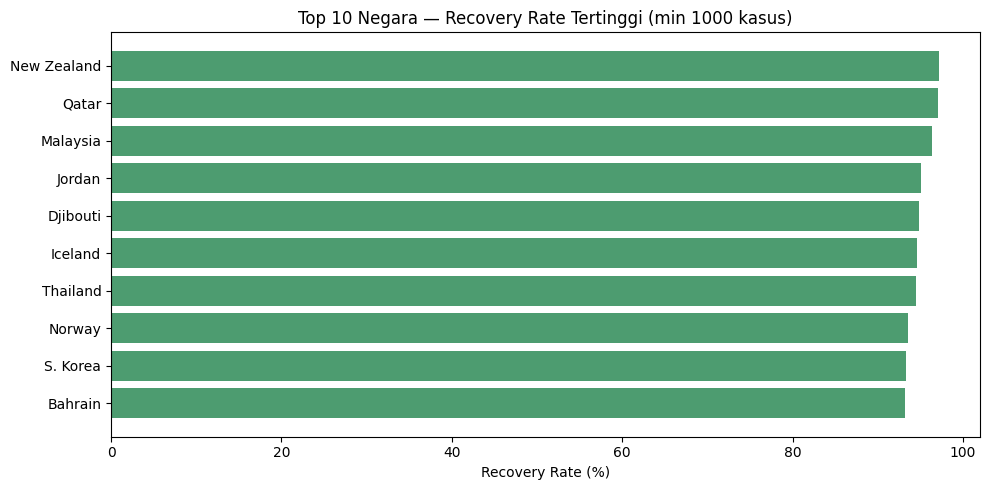

In [33]:
# Top 10 Recovery Rate tertinggi
df_perf = df.dropna(subset=['Death_Rate', 'Recovery_Rate', 'Tests/1M pop']).copy()
df_perf = df_perf[df_perf['TotalCases'] >= 1000]

top_recovery = df_perf.nlargest(10, 'Recovery_Rate')[
    ['Country/Region', 'TotalCases', 'TotalDeaths', 'TotalRecovered', 'Recovery_Rate']
].reset_index(drop=True)
display(top_recovery.round(2))

plt.figure(figsize=(10, 5))
plt.barh(top_recovery['Country/Region'][::-1],
         top_recovery['Recovery_Rate'][::-1], color='seagreen', alpha=0.85)
plt.xlabel('Recovery Rate (%)')
plt.title('Top 10 Negara — Recovery Rate Tertinggi (min 1000 kasus)')
plt.tight_layout()
plt.show()

,Country/Region,TotalCases,TotalDeaths,Death_Rate
0,Yemen,1768,508.0,28.73
1,France,195633,30312.0,15.49
2,Italy,249204,35187.0,14.12
3,Belgium,71158,9859.0,13.86
4,Hungary,4597,600.0,13.05
5,Mexico,462690,50517.0,10.92
6,Canada,118561,8966.0,7.56
7,Ireland,26372,1768.0,6.70
8,Ecuador,90537,5877.0,6.49
9,Sudan,11780,763.0,6.48


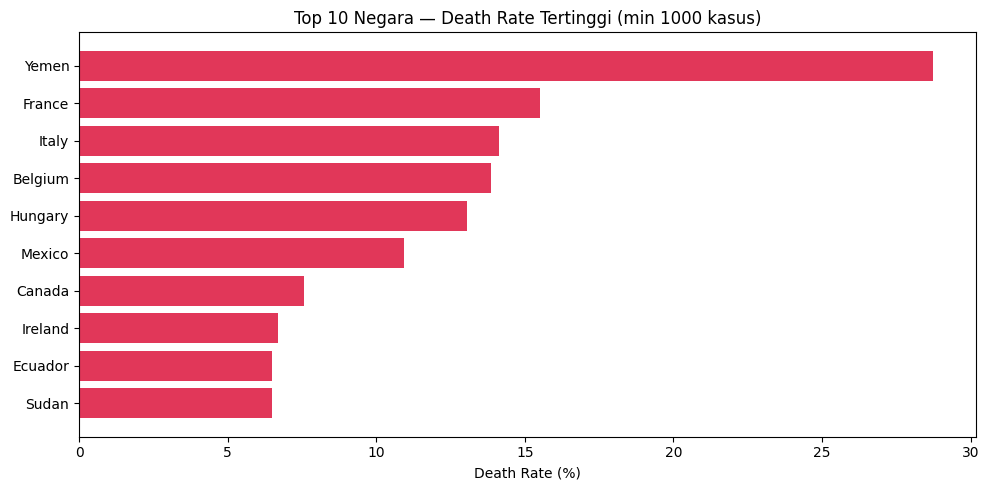

In [36]:
# Top 10 Death Rate tertinggi
top_death = df_perf.nlargest(10, 'Death_Rate')[
    ['Country/Region', 'TotalCases', 'TotalDeaths', 'Death_Rate']
].reset_index(drop=True)
display(top_death.round(2))

plt.figure(figsize=(10, 5))
plt.barh(top_death['Country/Region'][::-1],
         top_death['Death_Rate'][::-1], color='crimson', alpha=0.85)
plt.xlabel('Death Rate (%)')
plt.title('Top 10 Negara — Death Rate Tertinggi (min 1000 kasus)')
plt.tight_layout()
plt.show()

,Country/Region,TotalTests,Tests_per_1M
0,Luxembourg,623994.0,995282.0
1,Monaco,38209.0,972982.0
2,Faeroe Islands,43045.0,880590.0
3,Gibraltar,23063.0,684565.0
4,UAE,5262658.0,531470.0
5,Falkland Islands,1816.0,520493.0
6,Bahrain,876700.0,513691.0
7,Cayman Islands,31108.0,472780.0
8,Iceland,149693.0,438385.0
9,Bermuda,26352.0,423298.0


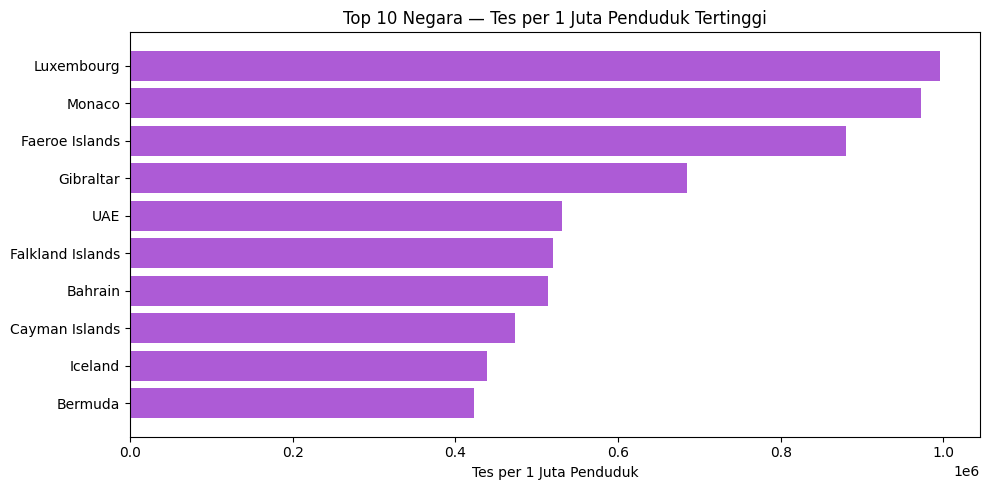

In [37]:
# Top 10 Tests/1M tertinggi
df_test = df.dropna(subset=['Tests/1M pop']).copy()
df_test['Tests_per_1M'] = pd.to_numeric(df_test['Tests/1M pop'], errors='coerce')
top_tests = df_test.nlargest(10, 'Tests_per_1M')[
    ['Country/Region', 'TotalTests', 'Tests_per_1M']
].reset_index(drop=True)
display(top_tests)

plt.figure(figsize=(10, 5))
plt.barh(top_tests['Country/Region'][::-1],
         top_tests['Tests_per_1M'][::-1], color='darkorchid', alpha=0.8)
plt.xlabel('Tes per 1 Juta Penduduk')
plt.title('Top 10 Negara — Tes per 1 Juta Penduduk Tertinggi')
plt.tight_layout()
plt.show()

Insight :

> Recovery rate tertinggi didominasi negara-negara Asia Timur dan Teluk Arab seperti Qatar (97.09%), S. Korea (93.28%), dan Bahrain (93.14%) negara dengan pengujian masif sejak awal  pandemi. Untuk death rate tertinggi, negara-negara dengan sistem kesehatan lemah atau respons  terlambat mendominasi. Dari sisi tests/1M penduduk, negara-negara kecil berpendapatan tinggi  memimpin  ini menunjukkan bahwa kapasitas pengujian lebih dipengaruhi oleh kemampuan ekonomi > dan kepadatan penduduk rendah daripada ukuran negara. Terdapat pola yang konsisten dimana  negara  dengan tests/1M tinggi cenderung memiliki positivity rate rendah dan recovery rate tinggi.

**8. Correlation Matrix**

> Buat heatmap korelasi untuk kolom numerik

> Apa yang menarik dari korelasi antara populasi, test, dan kasus?

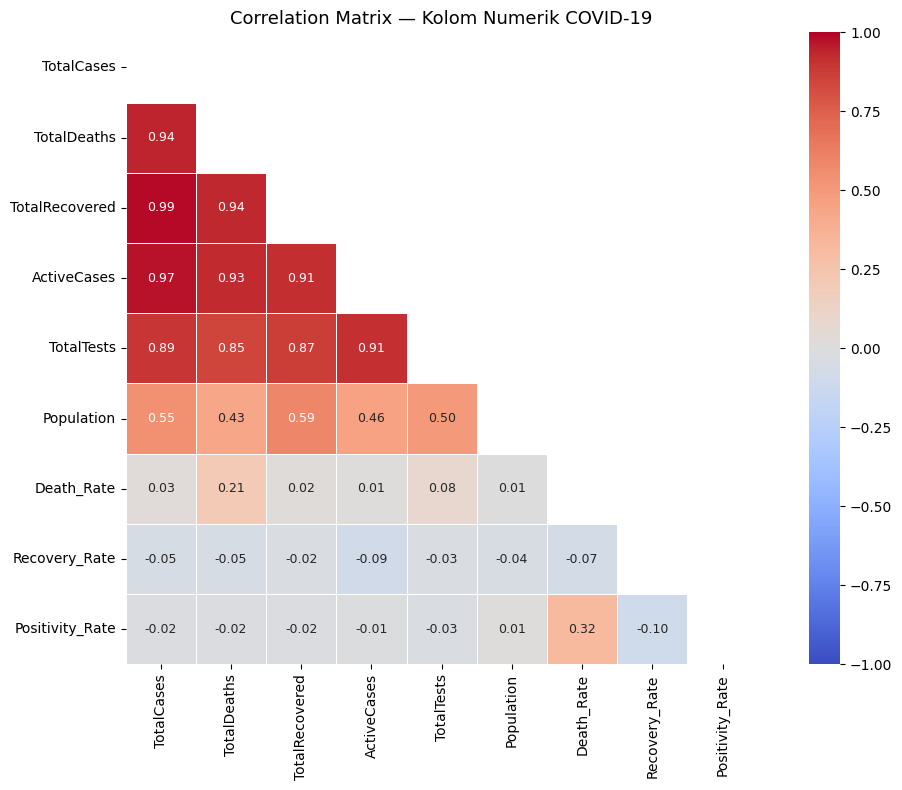

In [35]:
num_cols = ['TotalCases', 'TotalDeaths', 'TotalRecovered', 'ActiveCases',
            'TotalTests', 'Population', 'Death_Rate', 'Recovery_Rate', 'Positivity_Rate']

corr_df = df[num_cols].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix — Kolom Numerik COVID-19', fontsize=13)
plt.tight_layout()
plt.show()

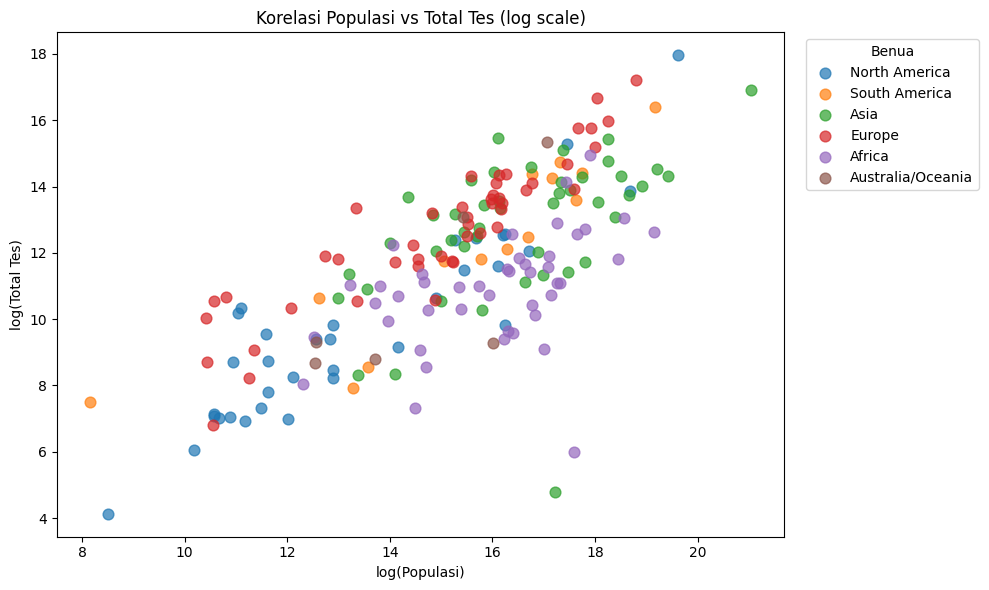

In [38]:
# Scatter Population vs TotalTests
df_corr = df.dropna(subset=['Population', 'TotalTests', 'Continent'])

plt.figure(figsize=(10, 6))
continents = df_corr['Continent'].unique()
palette = sns.color_palette('tab10', len(continents))

for continent, color in zip(continents, palette):
    sub = df_corr[df_corr['Continent'] == continent]
    plt.scatter(np.log1p(sub['Population']), np.log1p(sub['TotalTests']),
                label=continent, alpha=0.7, s=60, color=color)

plt.xlabel('log(Populasi)')
plt.ylabel('log(Total Tes)')
plt.title('Korelasi Populasi vs Total Tes (log scale)')
plt.legend(title='Benua', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight :

> Korelasi sangat kuat (+) terlihat antara TotalCases, TotalDeaths, TotalRecovered, dan  TotalTests karena semua dipengaruhi oleh ukuran populasi dan skala pandemi di suatu  negara. Population berkorelasi moderat dengan TotalCases, mengkonfirmasi bahwa populasi besar  bukan satu-satunya penentu jumlah kasus. Yang paling menarik: Positivity_Rate berkorelasi  negatif dengan TotalTests artinya  semakin banyak tes dilakukan, semakin rendah positivity rate, membuktikan bahwa pengujian masif adalah kunci untuk mendapatkan gambaran pandemi yang akurat.  Death_Rate dan Recovery_Rate berkorelasi negatif kuat secara matematis karena keduanya  merupakan komplemen satu sama lain dari TotalCases.

**9. Kesimpulan**

> Berikan kesimpulan soal dataset dan hasil EDA kamu.

Kesimpulan EDA Dataset COVID-19 Worldometer:

1. Distribusi kasus sangat tidak merata dimana USA, Brazil, India, dan Russia mendominasi lebih dari separuh kasus global, menunjukkan pola power-law pada penyebaran pandemi.

2. North America adalah episentrum yang memimpin total kasus (5,9 juta) dan kematian (229 ribu), dengan USA sebagai negara paling terdampak secara absolut (5,03 juta kasus,18.296 kasus kritis).

3. Kapasitas pengujian menentukan kualitas data, Sudan (positivity rate 2937%) dan  Yemen (1473%) menunjukkan betapa miskinnya data di negara berkonflik. Negara dengan  tests/1M tinggi secara konsisten memiliki positivity rate rendah.

4. Asia Timur dan Teluk Arab menunjukkan performa terbaik, Qatar, S. Korea, dan Bahrain memiliki recovery rate >93%.

5. Europe memiliki death rate relatif tinggi, meski kasusnya (2,9 juta) lebih rendah dari Asia (4,7 juta), kematiannya (205 ribu) hampir menyamai North America, kemungkinan karena struktur demografi yang lebih tua.

6. Populasi bukan satu-satunya faktor, korelasi populasi vs kasus hanya moderat. Kebijakan lockdown, kecepatan vaksinasi, dan kapasitas ICU terbukti lebih menentukan outcome pandemi suatu negara.